Prediction: Egyptian_cat (17.08)


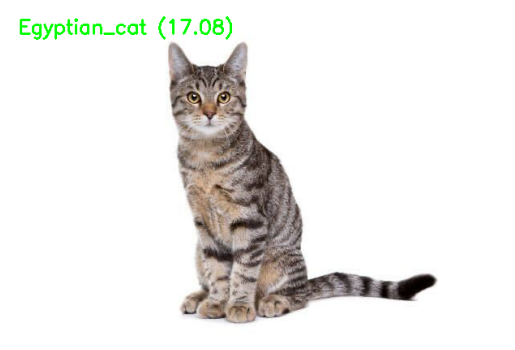

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Modeli yükle ----
# GoogleNet ONNX dosyanın yolunu buraya yaz
model_path = "googlenet-3.onnx"
net = cv2.dnn.readNetFromONNX(model_path)

# ---- 2. Görseli yükle ----
# Test etmek istediğin fotoğrafın yolunu yaz
image_path = "cat.jpg"
image = cv2.imread(image_path)

# Boyutları GoogleNet için (224x224)
blob = cv2.dnn.blobFromImage(
    image, 
    scalefactor=1.0, 
    size=(224, 224), 
    mean=(104, 117, 123),  # Caffe/GoogleNet ortalama değerleri
    swapRB=True, 
    crop=False
)

# ---- 3. Modele ver ----
net.setInput(blob)
out = net.forward()

# ---- 4. Sonuçları işle ----
# En yüksek olasılıklı sınıfı bul
idx = np.argmax(out[0])
confidence = out[0][idx]

with open("classes.txt") as f:
    labels = [line.strip() for line in f.readlines()]

label_text = f"{labels[idx]} ({confidence:.2f})"
print("Prediction:", label_text)

# ---- 6. Resmin üzerine yaz ----
output_img = image.copy()
cv2.putText(output_img, label_text, (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# ---- 7. Sonucu göster ----
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()